In [ ]:
import os
import json
import PIL
from PIL import Image
import numpy as np
import imagehash


## Generate Hashes

The process to generate hashes takes around 1 minute, so we will precompute them and dump to a json file

There is some minor processing of the images to change the transparent background to white, this may not be necessary - the original concept started with computing the cosine similarity and it has stuck

In [ ]:
hashes = {}
sprite_folder = "images/sprites/"
for filename in os.listdir(sprite_folder):
    if filename.endswith(".png"):
        path = os.path.join(sprite_folder, filename)
        with Image.open(path) as img:
            dex_num = filename.split('M')[0]

            ref = np.array(img.convert("RGBA"))
            ref[ref[...,3]==0,:3] = (255,255,255)
            ref_im = Image.fromarray(ref[...,:3])

            h = imagehash.crop_resistant_hash(ref_im)
            hashes[dex_num] = str(h)

with open('hashes.json', 'w') as f:
    json.dump(hashes, f)
            

## Load Hashes


In [69]:
with open('hashes.json', 'r') as f:
    hashes = json.load(f)


## Parameters

Here we define:

- image_scale: size used in emulator
- max_distance: placeholder for where a cut off could be used to switch over to manual intervention
- background 1/2: RGB values for the stripes, these are removed and set to white (may cause issues with some mons...)

- spacings/crop widths: these are values taken assuming the the top and left edge of the upper ds screen are cropped correctly

- remove background helper function...



In [ ]:
image_scale = 2


#  unused currently
max_distance = 5


background_1 = (243, 251, 186)
background_2  = (235, 251, 203)
obscuring_stripe = (227, 211, 146)

# This is actually the next screen with the board unfortuantely
# https://github.com/pret/pokeplatinum/blob/22a3e8ea307362a5eb8fea8fa979e7989205bcac/src/applications/frontier/battle_arcade/main.c#L818
# mon_y_offset = 46
# mon_y_spacing = 40


# So these values are just counted
inter_mon_spacing = 1
mon_height = 22
mon_width = 32
mon_shift = 6

left_edge = 200
crop_width = 50


## Cropping Images from Top Screen

We are assuming the crop is already completed, there are many ways it could be found - such as taking the midpoint, and from the top finding the first black pixel, and if necessary ensure the next is the yellow of the main arcade screen (no interruptions).

Similar methods could be used for locating the main screen horizontally

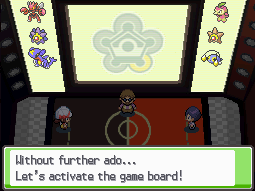

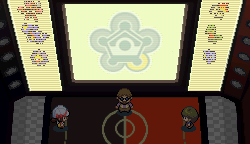

In [71]:
test_image = Image.open('images/test-image-2x.png')
(width, height) = (test_image.width // image_scale, test_image.height // image_scale)
test_image = test_image.resize((width, height), Image.Resampling.NEAREST)
test_image.show()

test_image_obs = Image.open('images/test-image-2x-obs.png')
(width, height) = (test_image_obs.width // image_scale, test_image_obs.height // image_scale)
test_image_obs = test_image_obs.resize((width, height), Image.Resampling.NEAREST)
test_image_obs.show()


## Checking the image is worth working with

We do not want to waste time with images which are obscurred, we can just capture another frame, fortunately the stripes which are used are a different colour, and alternate at a fixed spacing so we can do a simple check.

In [72]:
def check_obscured(
    image,
    crop: tuple[int, int, int, int],
    obscuring_stripe: tuple[int, int, int],
) -> bool:


    image_crop = image.crop(crop)
    data = np.array(image_crop.convert("RGB"))

    if data.size == 0:
        return False

    even_rows = np.all(data[::2, 0, :] == obscuring_stripe, axis=1)
    if np.all(even_rows):
        return True

    odd_rows = np.all(data[1::2, 0, :] == obscuring_stripe, axis=1)
    return bool(np.all(odd_rows))

In [73]:
upper = inter_mon_spacing + 5
lower = upper + 10
left = left_edge + crop_width //2
right = left + 1
crop = (left, upper, right, lower)

test_check = check_obscured(test_image, crop, obscuring_stripe)
test_check_obs = check_obscured(test_image_obs, crop, obscuring_stripe)

print(f"Unobscured image is{'' if test_check else ' not'} obscured")
print(f"Obscured image is{'' if test_check_obs else 'not'} obscured")


Unobscured image is not obscured
Obscured image is obscured


In [74]:
mon_patches = []
upper = inter_mon_spacing
lower = upper + mon_height
left = left_edge 
right = left + crop_width
for i in range(0, 3):
    crop = test_image.crop((left, upper, right, lower))
    mon_patches.append(crop.copy())
    upper += inter_mon_spacing + mon_height
    lower = upper + mon_height
    left -= mon_shift
    right -= mon_shift

## Matching the Mons


Here we use the precomputed hashes of the menu sprites, and the cropped patches from the emulator image to locate the closest matching mon


In [77]:
def remove_background(data: np.ndarray) -> None:
    red_s, green_s, blue_s = data.T 
    bg1 = (red_s == background_1[0]) & (green_s == background_1[1]) & (blue_s == background_1[2])
    bg2 = (red_s == background_2[0]) & (green_s == background_2[1]) & (blue_s == background_2[2])

    background = bg1 | bg2
    data[..., :][background.T] = (255, 255, 255)

In [78]:
closest_hash = []
closest_dex_num = "0"
for patch in mon_patches:
    data = np.array(patch.convert('RGB'))
    remove_background(data)
    patch = Image.fromarray(data)
    patch.show()

    patch_hash = imagehash.crop_resistant_hash(patch)

    min_dist = float("inf")
    for (dex_num, hash) in hashes.items():
        hash = imagehash.hex_to_multihash(hash)
        dist = patch_hash - hash
        if dist < min_dist:
            min_dist = dist
            closest_dex_num = dex_num
    closest_hash.append((min_dist, closest_dex_num))
    print(f"Closest: {closest_dex_num}, distance: {min_dist:.1f}")


Closest: 274, distance: 4.0


Closest: 120, distance: 4.0


Closest: 170, distance: 4.0
